### Astrostatistic Lecture 18

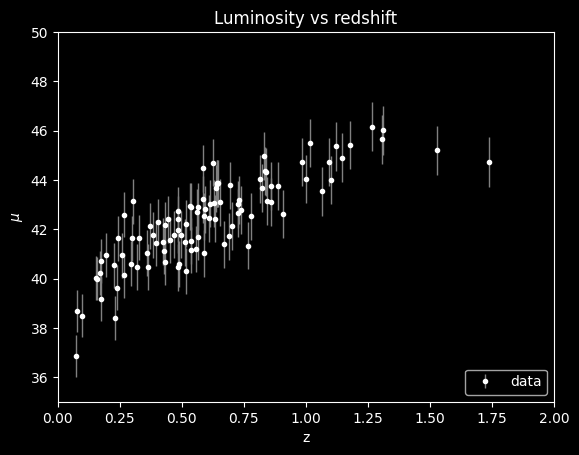

In [18]:
#capire che alpha usare su tutta sta roba se tenere 0.1 o mettere dmu
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import numpy as np
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

#just plot of the data 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

best-fit theta = -0.0572622284802237


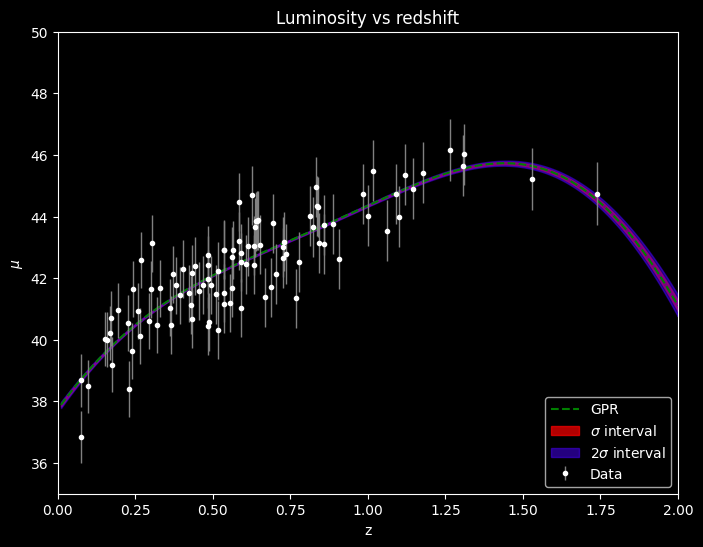

In [26]:
#try to fit the data with GPR
#we make the function pass into the data points
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=np.random.normal(mu_sample, 0.1)  #points in a distribution around the data

kernel = kernels.RBF(1, (0.01, 2.0))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, random_state=0)  #create the GPR

gp.fit(x[:, None], y)   #fit the GPR
predic, predic_err = gp.predict(x_test[:, None], 
                         return_std=True)          #predict

print("best-fit theta =", gp.kernel_.theta[0])

plt.figure(figsize=(8, 6))  #plot the GPR with confidence levels and the data 
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.7, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.5, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

 18%|█▊        | 18/100 [00:00<00:00, 91.05it/s]

CV error = 3.0423707879127764
train error = 0.14301216371858277
CV error = 3.007770121982006
train error = 0.1529428914889313
CV error = 2.9789745924260442
train error = 0.16324302863622278
CV error = 2.954667784154148
train error = 0.17472840967312606
CV error = 2.921692578339808
train error = 0.1881697388890961
CV error = 2.8668984811488354
train error = 0.20404298734319984
CV error = 2.7931992857741945
train error = 0.22274469201998373
CV error = 2.717384706687411
train error = 0.244250037060099
CV error = 2.658179570520595
train error = 0.26735655526804847
CV error = 2.6253778592127963
train error = 0.290023927792859
CV error = 2.618547065379377
train error = 0.3106224306998778
CV error = 2.6300307660374926
train error = 0.3287408541046512
CV error = 2.642779820647472
train error = 0.3452318112233316
CV error = 2.6342609472493783
train error = 0.36094054542315773
CV error = 2.5889572961872127
train error = 0.3754233368696121
CV error = 2.499057817459447
train error = 0.388197983986

 38%|███▊      | 38/100 [00:00<00:00, 91.06it/s]

CV error = 1.8556874771875218
train error = 0.43697788559656503
CV error = 1.722621477558252
train error = 0.4478664468003889
CV error = 1.610394441183871
train error = 0.4575016776591768
CV error = 1.5133136927218953
train error = 0.4665433404131226
CV error = 1.4323253445368354
train error = 0.4766944354529968
CV error = 1.372551804742465
train error = 0.4893946896564497
CV error = 1.3339085168327718
train error = 0.5044379201829795
CV error = 1.3087164780726817
train error = 0.5188991745835212
CV error = 1.2899957417619727
train error = 0.5304925584456485
CV error = 1.2762734618788685
train error = 0.539748839950497
CV error = 1.2671970938469457
train error = 0.5474731186711201
CV error = 1.2596512344075244
train error = 0.5539403336403217
CV error = 1.2496983603410425
train error = 0.560046305662401
CV error = 1.2339575945427803
train error = 0.5668582137557663
CV error = 1.2122552731493634
train error = 0.5747960829002272
CV error = 1.193022208632078
train error = 0.58569459817468

 48%|████▊     | 48/100 [00:00<00:00, 73.10it/s]

...

CV error = 0.9844519183510574
train error = 0.7297024104453895
CV error = 0.9892776871435014
train error = 0.7342404841301106
CV error = 0.9889612089756101
train error = 0.7402211536426966
CV error = 0.9915193495863914
train error = 0.7481370591944919
CV error = 1.0086528199478502
train error = 0.7570169338601455
CV error = 1.0304669432830242
train error = 0.7652125045513329
CV error = 1.039581176038308
train error = 0.7718551671802458
CV error = 1.034507261347011
train error = 0.7767872495711361
CV error = 1.0247697126340618
train error = 0.7801208740180849
CV error = 1.0176866591497296
train error = 0.7823661052190718
CV error = 1.0177616226364798
train error = 0.7842956707727448
CV error = 1.0295826313980112
train error = 0.7865803527616162
CV error = 1.0549766125135949
train error = 0.7897411834950236
CV error = 1.089153239136562
train error = 0.7942649550969473
CV error = 1.122253666374623
train error = 0.800444398497796


 83%|████████▎ | 83/100 [00:01<00:00, 80.77it/s]

CV error = 1.1448147483928537
train error = 0.8079957300675444
CV error = 1.1522160942334456
train error = 0.8159842778525863
CV error = 1.1458236033853268
train error = 0.8233019360721177
CV error = 1.1310675940353727
train error = 0.8292242880760078
CV error = 1.1140603298439797
train error = 0.8335568809712862
CV error = 1.0989894548224863
train error = 0.8364518392454434
CV error = 1.0875096204532126
train error = 0.8381967857429593
CV error = 1.0795863914380477
train error = 0.8391018627621538
CV error = 1.074580674903854
train error = 0.8394606394581665
CV error = 1.0718996878022231
train error = 0.8395407931526198
CV error = 1.071200265539113
train error = 0.839584911926036
CV error = 1.0723645949302787
train error = 0.839818567426101
CV error = 1.0754151179623876
train error = 0.8404650665538596
CV error = 1.08043308796227
train error = 0.8417616478620825
CV error = 1.0874894835145248
train error = 0.843968087760213
CV error = 1.0965852556719042
train error = 0.8473582597003313

100%|██████████| 100/100 [00:01<00:00, 80.72it/s]


CV error = 1.1637597993293447
train error = 0.8872298305184634
CV error = 1.1782010916347725
train error = 0.8987386168659194
CV error = 1.1917352194415411
train error = 0.9103744858296849
CV error = 1.2039884136809538
train error = 0.9216212228893834
CV error = 1.21473915112148
train error = 0.9320839322258481
CV error = 1.2239161795113893
train error = 0.9415273857190977
CV error = 1.2315752222667906
train error = 0.9498740209184297
CV error = 1.2378660075661672
train error = 0.9571760740214532
CV error = 1.2430001838497564
train error = 0.9635786481584528
CV error = 1.2472265943466592
train error = 0.9692859241421011
CV error = 1.2508161651000194
train error = 0.9745364485911263
CV error = 1.2540558141699294
train error = 0.9795886203790592
CV error = 1.2572494655208704
train error = 0.9847149028163455
CV error = 1.2607239615901604
train error = 0.9902024069577584
CV error = 1.264837859549561
train error = 0.9963575354808732
CV error = 1.269991386750886
train error = 1.0035127476697

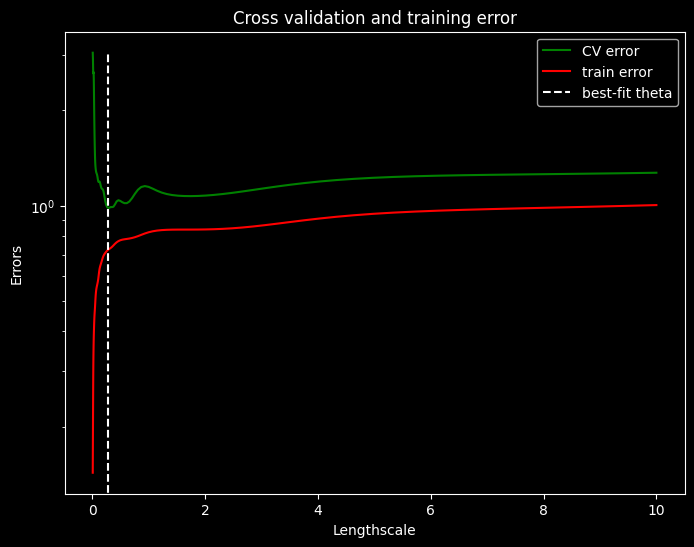

best-fit theta = 0.2848035868435802


In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
# now we need to do a cross validation on the GPR lengthscale

kf = KFold(n_splits=5, shuffle=True, random_state=42)   #use a 5-fold cross validation for the GPR lengthscale
scores=[]
t_scores=[]
lengthscale = np.logspace(-2, 1, 100)

for l in tqdm(lengthscale):     #cycle over the lengthscale
    fold_errors = []
    t_err = []
    for train_idx, test_idx in kf.split(x):     #for each l we do a 5-fold cross validation
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        dmu_train=dmu[train_idx]
        kernel=kernels.RBF(l, length_scale_bounds='fixed')
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, random_state=0, normalize_y=True)
        gp.fit(X_train[:, None], y_train)
        y_pred = gp.predict(X_test[:, None])
        error = error = np.mean(((y_test - y_pred) / dmu[test_idx])**2)
        fold_errors.append(error)
        train_error = mean_squared_error(y_train, gp.predict(X_train[:, None]))
        t_err.append(train_error)
    scores.append(np.mean(fold_errors))     #append the mean of the errors for test and train sets
    t_scores.append(np.mean(t_err))
    print(f"CV error = {scores[-1]}")
    print(f"train error = {t_scores[-1]}")
best_l = lengthscale[np.argmin(scores)]

plt.figure(figsize=(8, 6))      #plot the cross validation errors and training errors
plt.plot(lengthscale, scores, color='green', label='CV error')
plt.plot(lengthscale, t_scores, color='red', label='train error')
plt.vlines(best_l, 0, np.max(scores), color='white', ls='dashed', lw=1.5, label='best-fit theta')
plt.xlabel("Lengthscale")
plt.ylabel("Errors")
plt.title("Cross validation and training error")
plt.legend(loc='upper right')
plt.yscale('log')
plt.show()

print("best-fit theta =", best_l)     #best-fit lengthscale

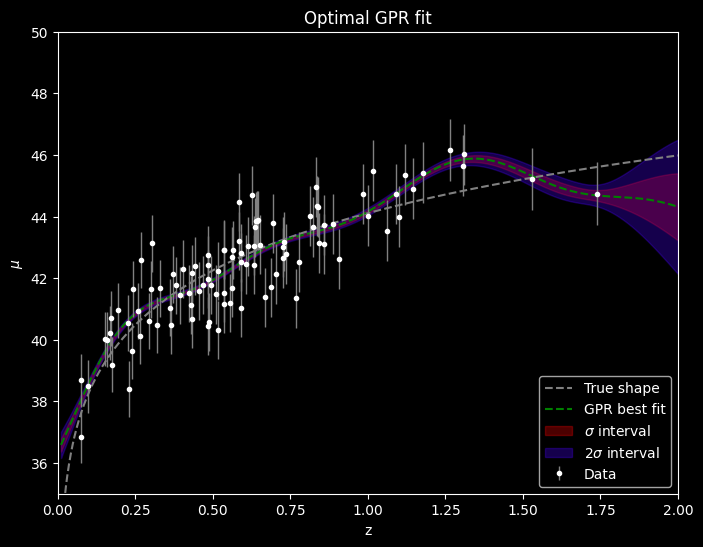

In [38]:
from astropy.cosmology import LambdaCDM

#true model
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

#best parametern fit and comparison
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=mu_sample

kernel = kernels.RBF(length_scale=best_l, length_scale_bounds="fixed")

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.1**2,
    normalize_y=True,
    random_state=0
)

gp.fit(x[:, None], y)

predic, predic_err = gp.predict(
    x_test[:, None],
    return_std=True
)

plt.figure(figsize=(8, 6))
plt.plot(z, mu_true, '--', c='gray', label='True shape')
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR best fit')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.3, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.3, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white', zorder=3)
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Optimal GPR fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

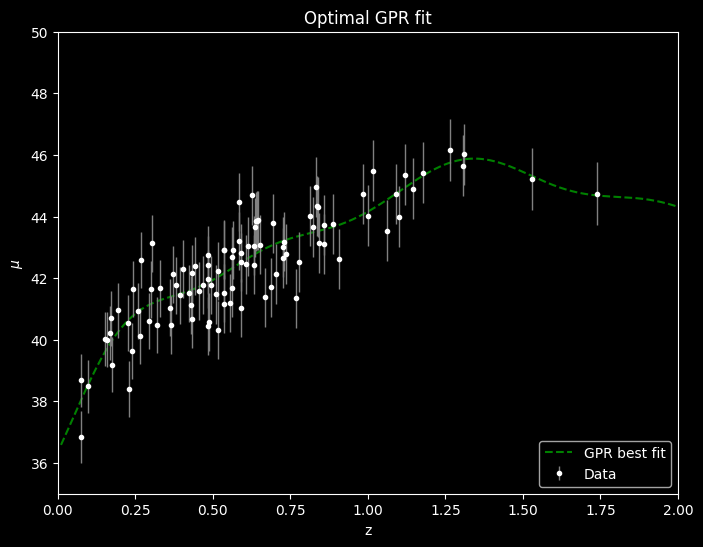

In [ ]:
#now from this fit we can get the pdf of the data and clone them to generate a bigger sample with same characteristics
#the distribution we are using is the GPR we fitted before and we just do a lazy rejection sampling in 2D

